In [1]:
# %load_ext cudf.pandas

In [2]:
# Suppress GDAL warnings in worker processes
import os
os.environ['CPL_LOG'] = '/dev/null' 

import ee
import numpy as np
from tqdm.notebook import tqdm
from osgeo import gdal
from rasterio.plot import show
import pandas as pd

import torch
from torchvision.transforms import Compose
from torch.utils.data import DataLoader
import torchgeo
from torchgeo.datasets import stack_samples

from forestvision.datasets import GNNForestAttr, GEESentinel2, GEE3Dep, GPDFeatureCollection
from forestvision.transforms import AppendNDVI, AppendNBR, AppendEVI, AppendSAVI, AppendNIRv, SelectBands
from forestvision.deploy import AnyRasterDataset
from forestvision.samplers import TileGeoSampler

In [3]:
torchgeo.__version__

'0.7.0'

In [4]:

REMAP = {
    33: 11, 112: 11, 128: 11, 165: 11, 182: 11, 198: 11, 306: 10, 346: 11,
    113: 11, 115: 11, 123: 11, 124: 11, 125: 10, 126: 11, 127: 11, 129: 10,
    130: 11, 131: 11, 132: 11, 133: 11, 134: 10, 135: 11, 136: 10, 148: 11,
    170: 10, 177: 11, 184: 11, 186: 11, 188: 10, 189: 10,
    190: 10, 191: 10, 192: 10, 193: 10, 196: 10, 197: 10, 199: 11,
    200: 10, 202: 10, 204: 10, 206: 10, 210: 10, 211: 10, 215: 10, 218: 10,
    219: 10, 220: 10, 221: 10, 231: 10, 234: 10, 238: 10, 254: 10, 256: 10,
    259: 10, 260: 10, 261: 10, 262: 10, 263: 10, 265: 10, 266: 10, 269: 10,
    270: 10, 271: 10, 272: 10, 282: 10, 284: 10, 286: 10, 293: 10, 319: 10,
    322: 10, 368: 10, 425: 11, 426: 10, 427: 10, 488: 10, 498: 10,
    518: 10, 535: 10, 543: 11, 545: 10, 546: 10, 565: 11, 568: 11, 569: 11,
    571: 11, 580: 11, 581: 10, 597: 11, 598: 10, 599: 11, 600: 11, 601: 10,
    602: 11, 603: 11, 604: 11, 605: 11, 606: 11, 607: 10, 608: 11, 610: 11,
    614: 10, 619: 10, 621: 11, 622: 11, 624: 11, 625: 11, 634: 11, 645: 10,
    647: 11, 653: 11, 654: 10, 667: 11, 668: 11, 669: 11, 670: 11, 672: 11,
    673: 11, 674: 11, 676: 11, 677: 11, 679: 11, 681: 11, 683: 11, 684: 11,
    685: 11, 689: 11, 690: 11, 698: 11, 701: 11, 702: 11, 703: 11, 704: 11,
    705: 11, 706: 11, 708: 11, 714: 11, 717: 10, 718: 11, 719: 11, 720: 11,
    721: 11, 723: 11, 726: 11, 728: 11, 743: 11, 748: 11, 752: 11, 767: 11,
    776: 11, 791: 11, 794: 11, 815: 10, 818: 10, 836: 11, 838: 11, 839: 11,
    840: 11, 841: 11, 844: 11, 852: 11, 855: 10, 886: 10, 887: 11, 888: 11,
    889: 11, 890: 10, 891: 10, 892: 11, 893: 10, 894: 11, 895: 11, 896: 10,
    897: 10, 898: 10, 899: 10, 900: 10, 901: 11, 902: 10, 906: 10, 907: 11,
    908: 11, 909: 11, 910: 11, 911: 11, 915: 11, 916: 11, 917: 11, 918: 11,
    919: 11, 921: 11, 926: 11, 930: 11, 931: 11, 932: 11, 935: 11, 942: 11,
    943: 11, 944: 11, 945: 11, 946: 11, 947: 11, 948: 11, 966: 9, 968: 9,
    969: 9, 975: 9,
}

GNNForestAttr.remap_dict.update(REMAP)

In [5]:
ee.Initialize(project='forestsegnet')

# Load and fetch datasets

In [6]:
class ClimateNA(AnyRasterDataset):
    all_bands = ["AHM", "MAP", "TD"]
    _cmap = None
    rgb_bands = ["AHM", "MAP", "TD"]  # Example RGB bands
    instrument = "ClimateNA"
    nodata = -9999.0

In [7]:

tiles = GPDFeatureCollection(
    tiles="../data/fortypba/tiles/train_120p10m.geojson")

ndvi = AppendNDVI(index_nir=7, index_red=3)
nbr = AppendNBR(index_nir=7, index_swir=11)
evi = AppendEVI(index_nir=7, index_red=3, index_blue=1)
savi = AppendSAVI(index_nir=7, index_red=3)
nirv = AppendNIRv(index_nir=7, index_red=3)
# selbands = SelectBands(indices=[
#     12, 13, 14, 15, 16  # Indices of appended bands
# ])
# transform = Compose([ndvi, nbr, evi, savi, nirv, selbands])
transform = Compose([ndvi, nbr, evi, savi, nirv])

s2lon = GEESentinel2(
    year=2021, 
    roi=tiles.bounds, 
    transforms=transform,
    path="../data/fortypba/training/geesentinel2_lon_120p10p", 
    download=True,
    # cache=False
)

s2loff = GEESentinel2(
    year=2021, 
    season="leafoff", 
    roi=tiles.bounds, 
    transforms=transform,
    path="../data/fortypba/training/geesentinel2_loff_120p10p", 
    download=True
    # cache=False
)

dep3d = GEE3Dep(
    roi=tiles.bounds, path="../data/fortypba/training/gee3dep120p10p", download=True)

climate = ClimateNA(
    paths="../data/fortypba/training/climatena", res=10, is_image=True)

input_dataset = s2lon & s2loff & dep3d & climate

print(climate.dtype)

torch.float32


In [8]:
paths = "../data/datasets/gnn/2021/"
gnn = GNNForestAttr(paths=paths, remap=False, res=10, crs="EPSG:5070")
gnn.is_image = True  # Hack to load as image dataset
# class_column.nodata = -1

In [9]:
dataset = gnn & input_dataset

In [10]:
def encode_bbox_centroid(bbox, precision=1e3):
    """
    Encodes x and y coordinates (EPSG:5070) into a single 64-bit integer.
    Precision determines the number of decimal places (1e3 gives 3 decimal places, mm resolution).
    """
    precision = int(precision)
    
    # Bounds for 5070, Oregon and Washington grid
    # We use the minimums to zero-base the values, keeping the integers as small as possible
    min_y = 2111115.79
    min_x = -2365773.06
    
    # Normalize coordinates to be positive and start from 0
    # This reduces the max value significantly compared to using the raw coordinates
    y = (bbox[2] + bbox[3]) / 2  # Centroid Y
    x = (bbox[0] + bbox[1]) / 2  # Centroid X
    y_norm = y - min_y
    x_norm = x - min_x
    
    # Scale and convert to integer
    lat_int = int(round(y_norm * precision))
    lon_int = int(round(x_norm * precision))
    
    # Verify bounds (optional but good for safety)
    if lat_int < 0 or lon_int < 0:
        # Fallback or error if points are outside the expected region
        # For now, we assume valid inputs as per the defined grid
        print("Coordinates out of bounds for encoding.")
        pass

    # With zero-basing:
    # Max Y range: ~1.1e6 * 1e3 = 1.1e9 (Fits in 31 bits)
    # Max X range: ~1.2e6 * 1e3 = 1.2e9 (Fits in 31 bits)
    
    shift_bits = 32 # Shift longitude by 32 bits
    
    # Combine
    # lat_int takes lower 32 bits, lon_int takes upper 32 bits
    encoded_int = (lon_int << shift_bits) | lat_int
    return encoded_int

# Get data for tile subset 

## Sample tiles with high representation of confused classes

In [11]:
import geopandas as gpd

In [12]:
gnn_cl_counts = pd.read_csv("../data/fortypba/tiles/train_120p10m_class_counts.csv")
tiles = gpd.read_file("../data/fortypba/tiles/train_120p10m.geojson")
if "odf_class" not in gnn_cl_counts.columns:
    gnn_cl_counts.insert(2, "odf_class", gnn_cl_counts.gnn_class.replace(gnn.remap_dict))
gnn_cl_counts.head()

,Unnamed: 0,hashes,gnn_class,odf_class,gnn_counts
0,0,a796df8175,-1,0,44
1,1,a796df8175,27,5,132
2,2,a796df8175,32,5,2
3,3,a796df8175,45,5,7
4,4,a796df8175,50,5,2


In [13]:
tiles.columns = ['geohash', 'geometry']
tiles.head()

,geohash,geometry
0,91fd6e44cb,"POLYGON ((-1689345 2427855, -1689345 2429055, ..."
1,66e958ad30,"POLYGON ((-1689345 2429055, -1689345 2430255, ..."
2,3709444852,"POLYGON ((-1688145 2427855, -1688145 2429055, ..."
3,e25ab86717,"POLYGON ((-1688145 2429055, -1688145 2430255, ..."
4,2955d45a46,"POLYGON ((-1902945 3145455, -1902945 3146655, ..."


In [14]:
odf_counts = (
    # gnn_cl_counts[gnn_cl_counts.odf_class.isin([2, 9,10,11])].drop("Unnamed: 0", axis=1)
    gnn_cl_counts[~gnn_cl_counts.odf_class.isin([-2147483648,-1])].drop("Unnamed: 0", axis=1)
            .groupby(["hashes", "gnn_class"]).sum()
)
# Weight sampling
counts = odf_counts.odf_class.value_counts()
odf_counts['weight'] = 1.0 / odf_counts.odf_class.map(counts)

odf_sam = odf_counts.sample(5000, weights=odf_counts['weight'])
tiles_sub = GPDFeatureCollection(tiles[tiles.geohash.isin(odf_sam.index.get_level_values(0).to_list())])
# tiles_sub.shape

In [15]:
balanced_dfs = []
target = 1000

for c in odf_counts['odf_class'].unique():
    # Filter by odf_class
    group = odf_counts[odf_counts['odf_class'] == c]
    
    # For each hash, keep only the gnn_class with highest counts
    # This reduces gnn_class diversity per tile
    group_filtered = group.loc[group.groupby(level='hashes')['gnn_counts'].idxmax()]
    
    # Sample to target size
    n = min(len(group_filtered), target)
    balanced_dfs.append(group_filtered.sample(n=n, replace=False, random_state=42))

remap_bal = pd.concat(balanced_dfs).sample(frac=1, random_state=42)
print('unique hashes:', len(remap_bal.reset_index().hashes.unique()))
remap_bal.odf_class.value_counts()

unique hashes: 13027


odf_class
2     1000
11    1000
3     1000
10    1000
6     1000
5     1000
8     1000
12    1000
4     1000
0     1000
1     1000
7     1000
9     1000
13    1000
Name: count, dtype: int64

(13027, 2)


<Axes: >

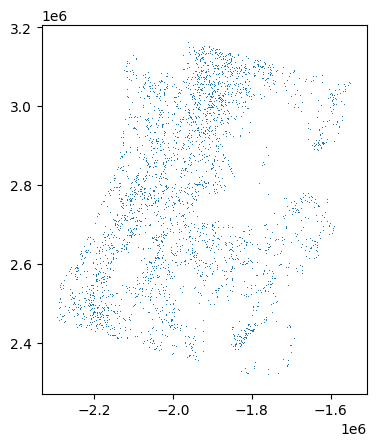

In [16]:
tiles_sub = GPDFeatureCollection(tiles[tiles.geohash.isin(remap_bal.index.get_level_values(0).to_list())])
print(tiles_sub.shape)
tiles_sub.plot()

In [17]:
p = round(tiles_sub.shape[0]*.8)
train  = tiles_sub.data.sample(p)
val = tiles_sub.data.drop(train.index)

In [ ]:
train.to_file("../data/dev/tiles/train_test_remap_120p10m.geojson", driver="GeoJSON")
val.to_file("../data/dev/tiles/val_test_remap_120p10m.geojson", driver="GeoJSON")
test_read = gpd.read_file("../data/dev/tiles/val_test_remap_120p10m.geojson")

In [ ]:
sampler = TileGeoSampler(
    dataset,
    tiles_sub.data,
    shuffle=False
)
dataloader = DataLoader(
    dataset,
    batch_size=5,
    sampler=sampler,
    collate_fn=stack_samples,
    num_workers=5
)

In [ ]:
filepath = '../data/fortypba/data_table.csv'
if os.path.exists(filepath):
    response = input(f"File {filepath} exists. Do you want to delete it (y/n)? ")
    if response.lower() == 'y':  
        os.remove(filepath)

In [ ]:
si = ['NDVI', 'NBR', 'EVI', 'SAVI', 'NIRv']
leafon_bands = [f'o{b}' for b in s2lon.bands] + [f'o{b}' for b in si] 
leafoff_bands = [f'f{b}' for b in s2loff.bands] + [f'f{b}' for b in si]
other_bands = ['DEM'] + [b for b in climate.bands]

In [ ]:
total_batches = 0 
for batch in tqdm(dataloader):
    # if total_batches == 1:
    #     break
    
    centroids = [encode_bbox_centroid(b) for b in batch["bounds"]]
    # Create centroid tensor for each pixel in the batch
    centroid_tensor = torch.tensor(centroids).unsqueeze(1).unsqueeze(2).unsqueeze(3)
    centroid_tensor = centroid_tensor.expand(-1, -1, batch['image'].shape[2], batch['image'].shape[3])
    centroid_flat = centroid_tensor.flatten()
        
    # Flatten spatial dimensions for mask, gnn, and image
    image_flat = batch['image'].reshape(batch['image'].shape[0], batch['image'].shape[1], -1)
    image_flat = image_flat.permute(0, 2, 1).reshape(-1, batch['image'].shape[1])
        
    # # Create a table with mask, gnn, and image channels
    data = torch.cat([image_flat, centroid_flat.unsqueeze(1)], dim=1)
    
    # Append to fil
    with open(filepath, 'a') as f:
        if total_batches == 0:
            # Write header
            columns = ['gnn'] + leafon_bands + leafoff_bands + other_bands + ['centroid']
            header = ','.join(columns)
            np.savetxt(f, data.cpu().numpy(), delimiter=',', header=header, comments='')
        else:
            np.savetxt(f, data.cpu().numpy(), delimiter=',')

    total_batches += 1
